Nom : KARBOUN Ahmed Master : GLCC

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#------------------------------------------
# préparation du dataset enrichi
#
# x contient les variables explicatives
#
# chaque colonne sera normalisée
# pour éviter qu'une variable
# domine les autres
#------------------------------------------

X = np.array([

    [2,5,8,20,0,6],
    [4,6,6,40,2,5],
    [6,7,5,60,3,4],
    [8,7,4,80,4,3],
    [10,8,3,90,5,2],

    [3,4,9,30,0,7],
    [7,6,5,70,3,4],
    [5,5,6,50,2,5],
    [9,8,4,85,4,3],
    [1,3,9,15,1,8],

    [6,6,5,65,3,4],
    [7,7,4,75,3,3],
    [8,8,3,88,4,2],
    [2,4,8,25,1,6],
    [3,5,7,35,2,6],

    [4,7,6,45,2,5],
    [5,6,6,55,3,4],
    [6,8,5,68,3,3],
    [7,5,5,72,4,3],
    [9,7,4,82,4,2],

    [10,9,3,95,5,1],
    [2,3,9,10,1,9],
    [3,4,8,28,2,7],
    [6,5,6,60,3,4],
    [7,6,5,70,3,3],

    [8,7,4,78,4,2],
    [9,8,3,88,5,2],
    [1,2,9,12,0,9],
    [2,6,7,22,1,7],
    [3,7,6,32,1,6],

    [4,8,5,42,2,5],
    [5,9,4,52,2,4],
    [6,3,8,62,3,5],
    [7,4,7,72,3,4],
    [8,5,6,82,4,3],

    [9,6,5,92,5,2],
    [10,7,4,98,5,1],
    [2,5,7,18,0,8],
    [3,6,6,28,1,7],
    [4,7,5,38,2,6],

    [5,8,4,48,2,5],
    [6,9,3,58,3,4],
    [7,3,9,68,3,6],
    [8,4,8,78,4,5],
    [9,5,7,88,4,4],

    [10,6,6,96,5,3],
    [1,7,8,14,1,8]

])

notes = np.array([

    10, 13, 15, 17, 18.5,
    11, 16, 12, 17, 9,

    14, 15, 18, 10, 11,
    13, 14, 15, 16, 17,

    19, 8, 9, 14, 15,
    16, 17, 7, 8, 9.5,

    10.5, 11.5, 12.5, 13.5, 14.5,
    15.5, 16.5, 17.5, 18, 19,

    20, 6, 7.5, 8.5, 9,
    10, 11

])

In [4]:
#------------------------------------------
# note >= 10 :
# réussite
#
# sinon :
# échec
#------------------------------------------

y_classe = (notes >= 10).astype(int)

#------------------------------------------
# normalisation z-score
#
#               x - μ
# x_norm = ----------------
#                  σ
#------------------------------------------

X_mean = np.mean(X, axis=0)

X_std = np.std(X, axis=0)

# éviter division par zéro

X_std[X_std == 0] = 1

X_norm = (X - X_mean) / X_std

In [5]:
#------------------------------------------
# distance de minkowski
#
# d(x,y)= ( Σ |xi - yi|^p )^(1/p)
#
# p = 1 -> manhattan
# p = 2 -> euclidienne
#------------------------------------------

def distance_minkowski(

    x1,
    x2,
    p=2

):

    return np.sum(

        np.abs(x1 - x2) ** p

    ) ** (1 / p)

In [6]:
#------------------------------------------
# récupération des k voisins
#------------------------------------------

def get_k_neighbors(

    X_train,
    y_train,
    x_test,
    K=3,
    p_metric=2

):

    distances = []

    for i in range(len(X_train)):

        d = distance_minkowski(

            x_test,
            X_train[i],
            p=p_metric

        )

        distances.append(

            (d, y_train[i])

        )

    # tri croissant distances

    distances.sort(

        key=lambda x: x[0]

    )

    # sélection k voisins

    k_voisins = distances[:K]

    return k_voisins

In [7]:
#------------------------------------------
# knn classification
#
# vote majoritaire
#------------------------------------------

def knn_classification(

    X_train,
    y_train,
    x_test,
    K=3,
    p_metric=2

):

    k_voisins = get_k_neighbors(

        X_train,
        y_train,
        x_test,
        K,
        p_metric

    )

    classes_voisins = [

        voisin[1]

        for voisin in k_voisins

    ]

    nb_1 = classes_voisins.count(1)

    nb_0 = classes_voisins.count(0)

    # gestion égalité

    if nb_1 >= nb_0:

        prediction = 1

    else:

        prediction = 0

    return prediction

In [8]:
#------------------------------------------
# knn régression
#
# moyenne des voisins
#------------------------------------------

def knn_regression(

    X_train,
    y_train,
    x_test,
    K=3,
    p_metric=2

):

    k_voisins = get_k_neighbors(

        X_train,
        y_train,
        x_test,
        K,
        p_metric

    )

    valeurs = [

        voisin[1]

        for voisin in k_voisins

    ]

    prediction = np.mean(valeurs)

    return prediction

In [9]:
#------------------------------------------
# étudiant test
#
# faible temps étude
# beaucoup absences
#------------------------------------------

etudiant_test = np.array([

    [2, 3, 9, 15, 0, 8]

])

# normalisation étudiant test

x_test_norm = (

    etudiant_test - X_mean

) / X_std

x_test_norm = x_test_norm.flatten()

print(x_test_norm)

[-1.34843864 -1.69600439  1.72557293 -1.59881408 -1.83576622  1.66271217]


In [10]:
#------------------------------------------
# paramètres
#------------------------------------------

SEUIL_REUSSITE = 10

# p = 1 -> manhattan
# p = 2 -> euclidienne

P_VAL = 1

liste_k = list(range(1, 11))

pred_notes = []

pred_classes = []

print(f"\nAnalyse KNN Minkowski p = {P_VAL}")

print("------------------------------------------")

for K in liste_k:

    note_finale = knn_regression(

        X_norm,
        notes,
        x_test_norm,
        K=K,
        p_metric=P_VAL

    )

    classe_finale = knn_classification(

        X_norm,
        y_classe,
        x_test_norm,
        K=K,
        p_metric=P_VAL

    )

    pred_notes.append(

        note_finale

    )

    pred_classes.append(

        classe_finale

    )

    print("\n----------------------")

    print(f"K = {K}")

    print(f"Note prédite = {note_finale:.2f}")

    if classe_finale == 1:

        print("Résultat : Réussite")

    else:

        print("Résultat : Échec")


Analyse KNN Minkowski p = 1
------------------------------------------

----------------------
K = 1
Note prédite = 9.00
Résultat : Échec

----------------------
K = 2
Note prédite = 8.50
Résultat : Échec

----------------------
K = 3
Note prédite = 8.00
Résultat : Échec

----------------------
K = 4
Note prédite = 8.75
Résultat : Échec

----------------------
K = 5
Note prédite = 10.50
Résultat : Échec

----------------------
K = 6
Note prédite = 10.42
Résultat : Réussite

----------------------
K = 7
Note prédite = 10.36
Résultat : Réussite

----------------------
K = 8
Note prédite = 10.19
Résultat : Réussite

----------------------
K = 9
Note prédite = 10.28
Résultat : Réussite

----------------------
K = 10
Note prédite = 10.05
Résultat : Réussite


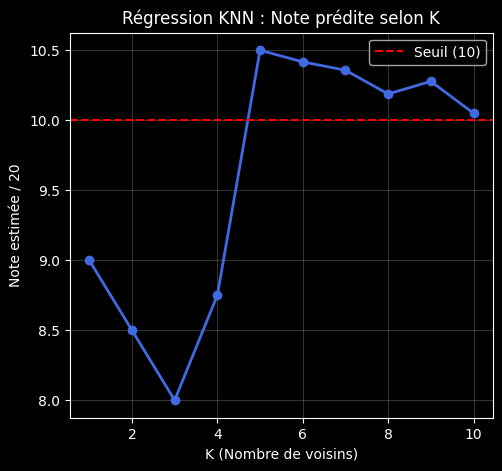

In [11]:
#------------------------------------------
# visualisation des prédictions de notes
#------------------------------------------

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(

    liste_k,
    pred_notes,
    marker='o',
    color='royalblue',
    linewidth=2

)

plt.axhline(

    y=SEUIL_REUSSITE,
    color='red',
    linestyle='--',
    label=f'Seuil ({SEUIL_REUSSITE})'

)

plt.title(

    "Régression KNN : Note prédite selon K"

)

plt.xlabel(

    "K (Nombre de voisins)"

)

plt.ylabel(

    "Note estimée / 20"

)

plt.legend()

plt.grid(

    True,
    alpha=0.2

)

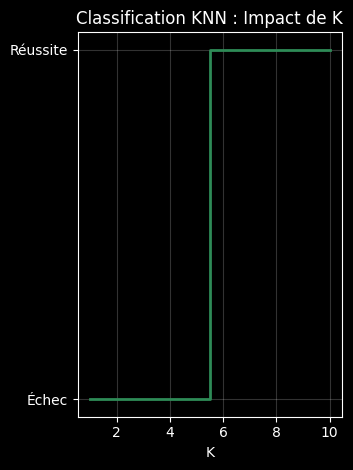

In [12]:
#------------------------------------------
# visualisation des prédictions de classes
#------------------------------------------

plt.subplot(1, 2, 2)

plt.step(

    liste_k,
    pred_classes,
    where='mid',
    color='seagreen',
    linewidth=2

)

plt.yticks(

    [0, 1],
    ["Échec", "Réussite"]

)

plt.title(

    "Classification KNN : Impact de K"

)

plt.xlabel(

    "K"

)

plt.grid(

    True,
    alpha=0.2

)

plt.tight_layout()

plt.show()